<a href="https://colab.research.google.com/github/Uwais-ur-Rehman/ML-Project/blob/main/SVM_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
numerical = ["age","balance","day","duration","campaign","pdays","previous"]

In [4]:
df=pd.read_csv('/content/bank marketing.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [5]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [8]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


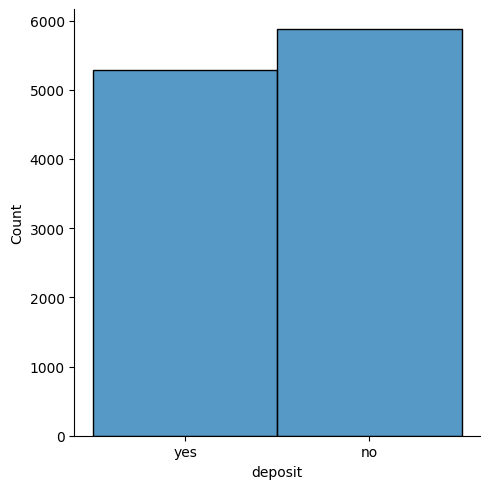

In [9]:
sns.displot(df['deposit'])
plt.show()

In [10]:
numerical = ["age","balance","day","duration","campaign","pdays","previous"]
categorical = ["job","marital","education","default","housing","loan","contact","month","poutcome"]
target = df["deposit"]

In [11]:
for col in categorical:
    print("\n", col)
    print(df[col].unique())


 job
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

 marital
['married' 'single' 'divorced']

 education
['secondary' 'tertiary' 'primary' 'unknown']

 default
['no' 'yes']

 housing
['yes' 'no']

 loan
['no' 'yes']

 contact
['unknown' 'cellular' 'telephone']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

 poutcome
['unknown' 'other' 'failure' 'success']


In [12]:
x = df.drop("deposit", axis=1)
y = df["deposit"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
for col in numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

age : 171
balance : 1055
day : 0
duration : 636
campaign : 601
pdays : 2750
previous : 1258


In [14]:
X = df.drop("deposit", axis=1)
y = df["deposit"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

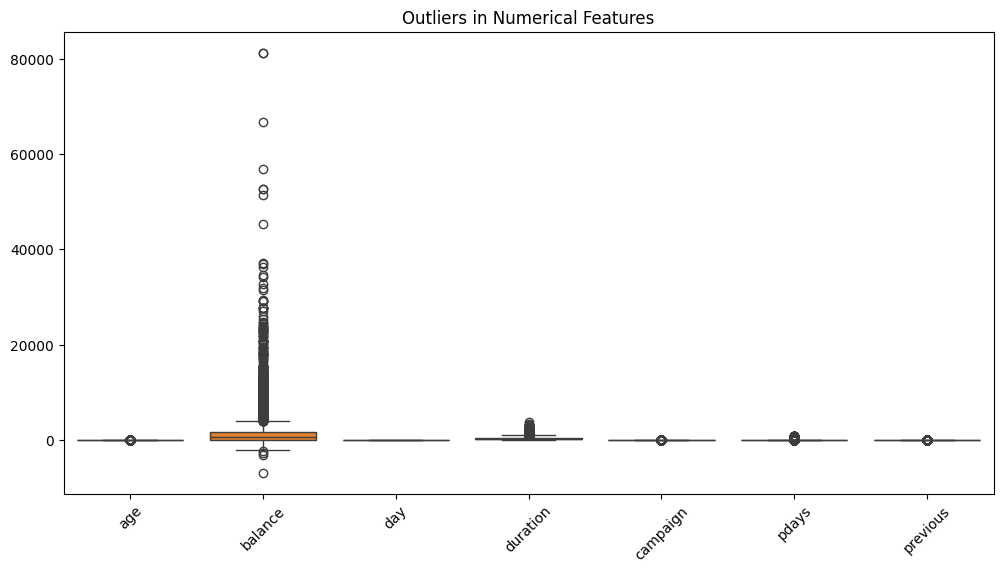

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical])

plt.xticks(rotation=45)
plt.title("Outliers in Numerical Features")
plt.show()

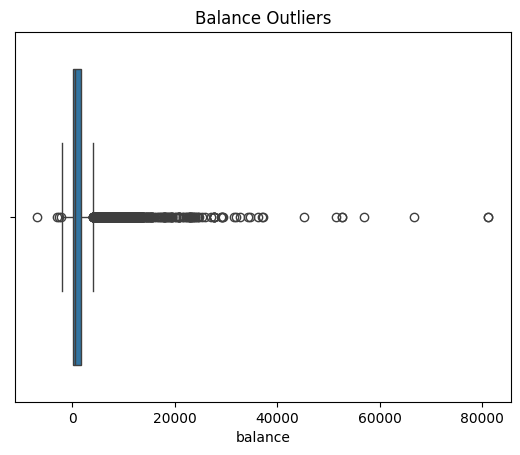

In [16]:
sns.boxplot(x=df["balance"])
plt.title("Balance Outliers")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first",sparse_output=False), categorical)
])

In [45]:
model=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",SVC(kernel="rbf"))
])

In [46]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('classifier', SVC())])

In [47]:
y_pred=model.predict(x_test)

In [48]:
model.score(x_test,y_test)*100

84.01253918495298

In [49]:
model.score(x_train,y_train)*100

87.75898756859671

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)*100

print("Accuracy:", accuracy)

Accuracy: 84.01253918495298


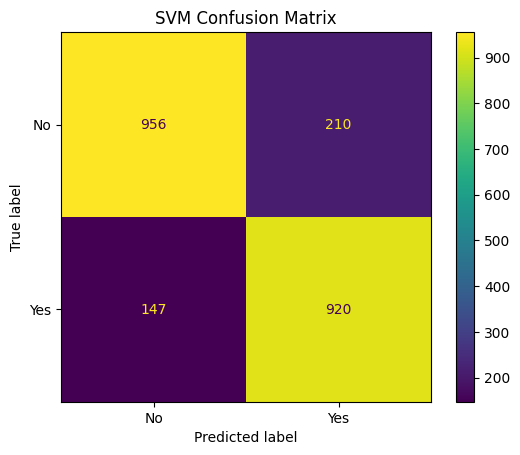

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No", "Yes"])

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, pos_label="yes")
recall = recall_score(y_test, y_pred, pos_label="yes")
f1 = f1_score(y_test, y_pred, pos_label="yes")

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8141592920353983
Recall: 0.8622305529522024
F1-score: 0.8375056895766955


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.87      0.82      0.84      1166
         yes       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

